# 2: n-grams

### Task 1

Prepare the corpus and tokens.

We reuse the completed Assignment 1 `BPETokenizer` and clean normalization, and the existing shared `evaluation.py` functions used by Assignment 3. The original `n_gram.py` is kept unchanged. Its initialization, training setup, and unigram counting are inherited by the `NGramLM` adapter; tuple keys and line-wise counting supply the required token-ID interface without concatenating ambiguous token strings.

Use a deterministic **80% training / 10% validation / 10% test split by line**, without shuffling. This gives the model most of the data while reserving equally sized validation and test sets. It is the same split already used by Assignment 3. Save the three clean split files, fit BPE only on training lines, and never reuse Assignment 1's 99%-trained merges here, since those would include held-out text.

Each line, including an empty line, is one sequence with `n-1` BOS tokens and one EOS token. BOS is context only; EOS is predicted. Character counts are the lengths of the original clean lines before tokenization, including spaces and punctuation but excluding line separators and synthetic markers. This denominator stays fixed across k and n and matches Assignment 3.

This section now establishes the functions, split, and three prompts previously described as provisional in Assignment 3. Both assignments use the same implementations; no earlier evaluation function is rewritten.

In [10]:
from pathlib import Path
import hashlib
import inspect
import json
import math
import platform
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Code
from bpe import BPETokenizer, normalize
from ngram import NGramLM
from n_gram import NGram
from evaluation import EncodedSequences, encode_lines, encode_file, perplexity, generate
from language_data import load_shakespeare, write_split_files

A2_START = time.perf_counter()
A2_SEED = 42
random.seed(A2_SEED)
np.random.seed(A2_SEED)
a2_results = Path('results/assignment2')
a2_models_dir = Path('models/assignment2')
a2_results.mkdir(parents=True, exist_ok=True)
a2_models_dir.mkdir(parents=True, exist_ok=True)
a2_lines = load_shakespeare()
a2_files = write_split_files(a2_lines)
print(f'Seed {A2_SEED}; {platform.platform()}; CPU')
display(pd.DataFrame([
    {'split': name, 'lines': len(lines), 'characters': sum(map(len, lines)),
     'file SHA-256': hashlib.sha256(a2_files[name].read_bytes()).hexdigest()}
    for name, lines in a2_lines.items()
]))
assert [len(a2_lines[s]) for s in ['train','val','test']] == [32000,4000,4000]
a2_tokenizers = {}
a2_tokenizer_times = {}
a2_encoded = {}
def a2_tokenizer(k):
    if k not in a2_tokenizers:
        started = time.perf_counter()
        tokenizer = BPETokenizer(num_merges=k).train('\n'.join(a2_lines['train']))
        a2_tokenizer_times[k] = time.perf_counter() - started
        tokenizer.save(a2_models_dir / f'bpe_{k}.json')
        a2_tokenizers[k] = tokenizer
    return a2_tokenizers[k]

def a2_sequences(k, n, split):
    key = (k, n, split)
    if key not in a2_encoded:
        a2_encoded[key] = encode_file(a2_tokenizer(k), a2_files[split], n=n)
    return a2_encoded[key]

a2_tok = a2_tokenizer(1000)
a2_initial_ids = {split: a2_sequences(1000, 3, split) for split in a2_lines}
print('Initial k=1000; V =', len(a2_tok.vocab))
display(pd.DataFrame([
    {'split': split, 'sequences': len(sequences),
     'predicted tokens (including EOS)': sum(len(s)-2 for s in sequences),
     'UNK tokens': sum(s.count(a2_tok.unk_id) for s in sequences)}
    for split, sequences in a2_initial_ids.items()
]))
print('Example padded sequence:', a2_initial_ids['train'][0])
print('Symbols:', [a2_tok._id_to_token[i] for i in a2_initial_ids['train'][0]])
assert all(s[:2] == [a2_tok.bos_id]*2 and s[-1] == a2_tok.eos_id
           for sequences in a2_initial_ids.values() for s in sequences)

Seed 42; macOS-15.7.1-arm64-arm-64bit; CPU


,split,lines,characters,file SHA-256
0,train,32000,875150,e4c055399b607de2a4f58b4e877441eaa7d3fe4ff6f813...
1,val,4000,105074,ed866c069ef1b5c94d9865c2a8dc945a4edaf62c248105...
2,test,4000,95152,b0ebc588f356579b269b4f6bbcaf94f4087212307f95de...


Initial k=1000; V = 1043


,split,sequences,predicted tokens (including EOS),UNK tokens
0,train,32000,460656,0
1,val,4000,57506,0
2,test,4000,53483,0


Example padded sequence: [0, 0, 381, 5, 813, 1]
Symbols: ['<bos>', '<bos>', 'first</w>', ' ', 'citizen:</w>', '<eos>']


### Task 2

The n-gram engine and hand checks.

For every supported order $n\in\{1,2,3\}$, use add-one smoothing everywhere:

$$P(w\mid h)=\frac{c(h,w)+1}{c(h)+V}.$$

An unseen history has both counts zero, giving exactly $1/V$ for every token. For a unigram the history is the empty tuple and its count is the total number of predicted tokens. Count histories only at positions with a target, so the outgoing n-gram counts sum to their history count. Sequence boundaries prevent EOS from becoming the history of the following line.

The adapter retains our original `NGram.__init__`, `NGram.train`, and `count_unigrams` methods. The original higher-order counters concatenate strings (which loses boundaries), or add integer IDs if passed IDs, so they cannot be reused unchanged for this interface. All model code uses only the standard library and NumPy.

Toy corpus: **ab, ab, ac, b, a**. IDs are BOS=0, EOS=1, UNK=2, a=3, b=4, c=5, so V=6. In the bigram model, history a occurs four times and is followed by b twice, giving $P(b\mid a)=(2+1)/(4+6)=0.3$. History b occurs three times and is always followed by EOS, giving $P(\mathrm{EOS}\mid b)=(3+1)/(3+6)=4/9$.

In [11]:
display(Code(inspect.getsource(NGramLM), language='python'))
print('Original unigram counter, inherited unchanged:')
display(Code(inspect.getsource(NGram.count_unigrams), language='python'))
a2_toy_words = [[3,4], [3,4], [3,5], [4], [3]]
a2_toy_models = {}
for order in [1,2,3]:
    sequences = EncodedSequences([[0]*(order-1) + word + [1] for word in a2_toy_words], 8)
    lm = NGramLM(n=order, vocab_size=6).fit(sequences)
    a2_toy_models[order] = lm
    assert sum(lm.ngram_counts.values()) == 13  # eight characters plus five EOS
    assert sum(lm.context_counts.values()) == 13
    for history in lm.context_counts:
        assert np.isclose(np.exp(lm.next_token_log_probs(history)).sum(), 1.0)
        assert sum(lm.ngram_counts[history+(t,)] for t in range(6)) == lm.context_counts[history]
        assert 1 not in history  # no contexts cross a line boundary
    if order > 1:
        assert np.allclose(np.exp(lm.next_token_log_probs([2]*(order-1))), np.full(6,1/6))
assert a2_toy_models[1].context_counts[()] == 13
assert np.isclose(np.exp(a2_toy_models[1].log_prob(3, [])), 5/19)
a2_manual = pd.DataFrame([
    {'probability': 'P(b | a)', 'by hand': 3/10,
     'code': np.exp(a2_toy_models[2].log_prob(4, [3]))},
    {'probability': 'P(EOS | b)', 'by hand': 4/9,
     'code': np.exp(a2_toy_models[2].log_prob(1, [4]))},
])
display(a2_manual)
assert np.allclose(a2_manual['by hand'], a2_manual['code'])
print('All three orders, normalized distributions, unseen histories, and both hand calculations passed.')

class NGramLM(NGram):
    def __init__(self, n, vocab_size):
        super().__init__(n)
        self.vocab_size = vocab_size
        self.vocabulary_size = vocab_size
        self.ngram_counts = Counter()
        self.context_counts = Counter()

    def fit(self, sequences):
        super().train([t for sequence in sequences for t in sequence[self.n - 1:]])
        self.vocabulary_size = self.vocab_size
        self.unigram_counts = self.count_unigrams()
        self.ngram_counts.clear()
        self.context_counts.clear()
        for sequence in sequences:
            for i in range(self.n - 1, len(sequence)):
                context = tuple(sequence[i - self.n + 1:i])
                self.ngram_counts[context + (sequence[i],)] += 1
                self.context_counts[context] += 1
        return self

    def log_prob(self, token, context):
        context = tuple(context)
        return math.log((self.ngram_counts[context + (token,)] + 1) /
                        (self.context_counts[context] + self.vocab_size))

    def next_token_log_probs(self, context):
        return np.array([self.log_prob(token, context) for token in range(self.vocab_size)])

    @property
    def stored_counts(self):
        return len(self.ngram_counts) + len(self.context_counts) + len(self.unigram_counts)

Original unigram counter, inherited unchanged:


def count_unigrams(self):
        return Counter(self.corpus)

,probability,by hand,code
0,P(b | a),0.300000,0.300000
1,P(EOS | b),0.444444,0.444444


All three orders, normalized distributions, unseen histories, and both hand calculations passed.


### Task 3

Shared perplexity and the unigram sanity check.

`perplexity` is model-independent: it calls `log_prob` and never accesses count dictionaries. Accumulate negative log probabilities, then exponentiate:

$$\mathrm{PP}=\exp(\mathrm{NLL}/N),\qquad\mathrm{PP}_{char}=\exp(\mathrm{NLL}/C).$$

$N$ includes EOS but excludes BOS. $C$ counts the clean original characters before tokenization, excluding separators and markers. `EncodedSequences` is a list of ID sequences carrying this character count. Use PP/character to compare different k values because their predicted units have different lengths.

For the random-data check, save exactly **200 seeded uniform content-token IDs** to JSON, read them back, and append one EOS for evaluation (201 predicted tokens). Exclude special and empty-decoding tokens from random content. Its character denominator is the length of the decoded random content; that per-character value is only a synthetic sanity check, not a natural-text benchmark.

In [12]:
display(Code(inspect.getsource(perplexity), language='python'))
a2_unigram = NGramLM(1, len(a2_tok.vocab)).fit(a2_sequences(1000,1,'train'))
a2_train_pp = perplexity(a2_unigram, a2_sequences(1000,1,'train'))
a2_rng = np.random.default_rng(A2_SEED)
a2_content_ids = [i for i in range(len(a2_tok.vocab))
                  if i not in [a2_tok.bos_id,a2_tok.eos_id,a2_tok.unk_id] and a2_tok.decode([i])]
a2_random_ids = a2_rng.choice(a2_content_ids, size=200).tolist()
a2_random_file = a2_results / 'random_200_ids.json'
a2_random_file.write_text(json.dumps(a2_random_ids))
a2_random_ids = json.loads(a2_random_file.read_text())
assert len(a2_random_ids) == 200
a2_random_sequences = EncodedSequences([a2_random_ids+[a2_tok.eos_id]],
                                      len(a2_tok.decode(a2_random_ids)))
a2_random_pp = perplexity(a2_unigram, a2_random_sequences)
display(pd.DataFrame([a2_train_pp,a2_random_pp],
    index=['Unigram on its training text','Unigram on 200 random IDs + EOS'],
    columns=['PP/token','PP/character']))
display(Markdown(f"The training PP/token is {a2_train_pp[0]:.3f}: frequent training tokens receive more probability, so this measures fit to the learned frequency distribution."))
display(Markdown(f"The random-file PP/token is {a2_random_pp[0]:.3f}: uniform token sampling presents rare training tokens more often and therefore produces a larger cross-entropy than the training text."))
assert a2_random_pp[0] > a2_train_pp[0]
# A uniform model gives an exact independent check of both denominators.
class A2UniformModel:
    n = 3
    def log_prob(self, token, context):
        return -math.log(6)
a2_uniform_ids = EncodedSequences([[0,0,3,4,1]], character_count=2)
assert np.allclose(perplexity(A2UniformModel(),a2_uniform_ids),(6,6**1.5))
print('Uniform-model check: 3 predictions / 2 original characters; BOS excluded, EOS included.')

def perplexity(model, sequences):
    negative_log_likelihood, predicted_tokens = 0.0, 0
    for sequence in sequences:
        for i in range(model.n - 1, len(sequence)):
            context = sequence[i - model.n + 1:i]
            negative_log_likelihood -= model.log_prob(sequence[i], context)
            predicted_tokens += 1
    if predicted_tokens == 0 or sequences.character_count <= 0:
        raise ValueError("Perplexity needs predicted tokens and a positive character count.")
    return (math.exp(negative_log_likelihood / predicted_tokens),
            math.exp(negative_log_likelihood / sequences.character_count))

,PP/token,PP/character
Unigram on its training text,122.380759,12.557912
Unigram on 200 random IDs + EOS,2977.770318,10.825491


The training PP/token is 122.381: frequent training tokens receive more probability, so this measures fit to the learned frequency distribution.

The random-file PP/token is 2977.770: uniform token sampling presents rare training tokens more often and therefore produces a larger cross-entropy than the training text.

Uniform-model check: 3 predictions / 2 original characters; BOS excluded, EOS included.


### Task 4

Validation-only model selection.

Train all 15 combinations: `k ∈ {250, 500, 1000, 2000, 4000}` and `n ∈ {1, 2, 3}`. Every BPE tokenizer and count model sees training text only. Choose the pair with the lowest **validation PP/character**, breaking exact ties by smaller n then k. Freeze that choice before computing any test perplexity; the test UNK counts shown in Task 1 are a data check, not a model score.

After selection, evaluate the three orders at the selected k on the test set exactly once each. Keep the choice even if another order happens to score better on the test set. No retraining on validation data is performed.

n=1, k=250: validation PP/token=86.092; PP/character=19.859


n=2, k=250: validation PP/token=21.433; PP/character=7.814


n=3, k=250: validation PP/token=22.596; PP/character=8.096


n=1, k=500: validation PP/token=106.991; PP/character=16.532


n=2, k=500: validation PP/token=30.991; PP/character=7.857


...

n=1, k=4000: validation PP/token=143.438; PP/character=10.058


n=2, k=4000: validation PP/token=186.634; PP/character=11.367


n=3, k=4000: validation PP/token=355.855; PP/character=15.343


k,250,500,1000,2000,4000
n,,,,,
1,19.8592,16.5324,14.1284,11.5212,10.0575
2,7.8142,7.8573,8.5712,9.8214,11.3667
3,8.0961,9.5761,11.6314,13.3505,15.3433


,n,k,V,validation_pp,validation_pp_char,stored_counts,training_seconds
0,1,250,293,86.09227,19.85922,579,0.13477
1,2,250,293,21.43301,7.81416,9076,0.17531
2,3,250,293,22.59594,8.09609,57753,0.19770
3,1,500,543,106.99139,16.53238,1077,0.12728
4,2,500,543,30.99110,7.85735,13949,0.16511
5,3,500,543,43.08632,9.57610,84159,0.18264
6,1,1000,1043,126.30857,14.12844,2063,0.11851
7,2,1000,1043,50.67979,8.57116,20527,0.15070
8,3,1000,1043,88.53280,11.63139,111761,0.17390
9,1,2000,2043,136.76112,11.52117,4043,0.10427


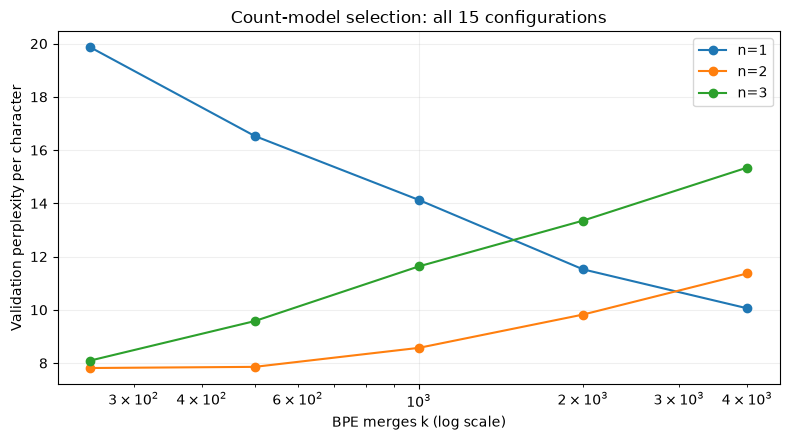

Validation selects **n=2, k=250**, with PP/character 7.8142. The curves show that n=1 falls with k; n=2 rises with k; n=3 rises with k, reflecting the trade-off between longer tokens and sparser counts under add-one smoothing.

Choice frozen before any test perplexity is computed.


In [13]:
A2_KS = [250,500,1000,2000,4000]
a2_grid_models = {}
a2_grid_rows = []
for k in A2_KS:
    tokenizer = a2_tokenizer(k)
    for order in [1,2,3]:
        train_sequences = a2_sequences(k,order,'train')
        validation_sequences = a2_sequences(k,order,'val')
        started = time.perf_counter()
        candidate = NGramLM(order,len(tokenizer.vocab)).fit(train_sequences)
        fit_seconds = time.perf_counter() - started
        pp, pp_char = perplexity(candidate,validation_sequences)
        a2_grid_models[(order,k)] = candidate
        a2_grid_rows.append(dict(n=order,k=k,V=len(tokenizer.vocab),
            validation_pp=pp,validation_pp_char=pp_char,
            stored_counts=candidate.stored_counts,training_seconds=fit_seconds))
        print(f'n={order}, k={k}: validation PP/token={pp:.3f}; PP/character={pp_char:.3f}',flush=True)
a2_grid = pd.DataFrame(a2_grid_rows)
a2_validation_table = a2_grid.pivot(index='n',columns='k',values='validation_pp_char')
display(a2_validation_table.round(4))
display(a2_grid.round(5))
fig, ax = plt.subplots(figsize=(8,4.5))
for order in [1,2,3]:
    rows = a2_grid.query('n == @order').sort_values('k')
    ax.plot(rows['k'],rows['validation_pp_char'],marker='o',label=f'n={order}')
ax.set_xscale('log')
ax.set(xlabel='BPE merges k (log scale)',ylabel='Validation perplexity per character',
       title='Count-model selection: all 15 configurations')
ax.legend()
ax.grid(alpha=.2)
fig.tight_layout()
plt.show()
a2_winner = min(a2_grid_rows,key=lambda row:(row['validation_pp_char'],row['n'],row['k']))
a2_best_n,a2_best_k = a2_winner['n'],a2_winner['k']
a2_best_model = a2_grid_models[(a2_best_n,a2_best_k)]
a2_best_tok = a2_tokenizers[a2_best_k]
(a2_results/'selection_before_test.json').write_text(json.dumps(a2_winner,indent=2))
a2_shapes=[]
for order in [1,2,3]:
    values=a2_validation_table.loc[order].to_numpy()
    shape='rises with k' if np.all(np.diff(values)>=0) else 'falls with k' if np.all(np.diff(values)<=0) else 'is non-monotonic'
    a2_shapes.append(f'n={order} {shape}')
display(Markdown(f"Validation selects **n={a2_best_n}, k={a2_best_k}**, with PP/character {a2_winner['validation_pp_char']:.4f}. The curves show that {'; '.join(a2_shapes)}, reflecting the trade-off between longer tokens and sparser counts under add-one smoothing."))
print('Choice frozen before any test perplexity is computed.')
a2_grid.to_csv(a2_results/'validation_grid_long.csv',index=False)
a2_validation_table.to_csv(a2_results/'validation_grid.csv')

In [14]:
# Final test phase: one evaluation per requested model at the chosen k.
a2_test_rows=[]
for order in [1,2,3]:
    pp,pp_char=perplexity(a2_grid_models[(order,a2_best_k)],a2_sequences(a2_best_k,order,'test'))
    a2_test_rows.append(dict(n=order,k=a2_best_k,selected_on_validation=order==a2_best_n,
                             test_pp=pp,test_pp_char=pp_char))
a2_test_table=pd.DataFrame(a2_test_rows)
display(a2_test_table.round(5))
a2_test_table.to_csv(a2_results/'test_comparison.csv',index=False)
print('The validation-selected model is retained; test results do not change the choice.')

,n,k,selected_on_validation,test_pp,test_pp_char
0,1,250,False,87.11065,20.62280
1,2,250,True,23.47393,8.48274
2,3,250,False,27.28340,9.39256


The validation-selected model is retained; test results do not change the choice.


### Task 5

Generation and stopping behavior.

Use the selected model and the same three prompts as Assignment 3: **shall i compare thee**, **to be or not to be**, and **first citizen**. Produce ten outputs per mode, cycling through the prompts in the same order (4/3/3 outputs across prompts), with seed `42+i` and a 50-token limit. The shared `generate` function normalizes and encodes the prompt, supplies BOS context, calls the model's probability interface, and either samples or takes argmax. It returns decoded text with an explicit EOS/limit stopping reason.

To count loops without changing generation, a small wrapper records contexts passed to the model. For deterministic argmax with a fixed context window, a repeated context before EOS proves a cycle: the same next token and subsequent contexts recur. Report that as an argmax loop. For sampling, report how many outputs reach EOS in fewer than 50 generated tokens; repeated contexts alone do not prove a sampling loop. The generator itself contains no count-model logic.

In [15]:
display(Code(inspect.getsource(generate),language='python'))
class A2GenerationTrace:
    def __init__(self, model):
        self.model=model
        self.n=model.n
        self.contexts=[]
    def next_token_log_probs(self,context):
        self.contexts.append(tuple(context))
        return self.model.next_token_log_probs(context)

a2_prompts=['shall i compare thee','to be or not to be','first citizen']
a2_samples=[]
for mode in ['argmax','sample']:
    for i in range(10):
        prompt=a2_prompts[i%3]
        trace=A2GenerationTrace(a2_best_model)
        text=generate(trace,a2_best_tok,prompt,mode=mode,max_tokens=50,seed=A2_SEED+i)
        reached_eos=text.endswith(' [stopped: <eos>]')
        loop=(mode=='argmax' and len(set(trace.contexts))<len(trace.contexts))
        a2_samples.append(dict(mode=mode,number=i+1,prompt=prompt,seed=A2_SEED+i,
            generated_tokens=len(trace.contexts),argmax_loop=loop,
            eos_before_limit=reached_eos and len(trace.contexts)<50,text=text))
        print(f'\n{mode.upper()} {i+1} | seed={A2_SEED+i} | prompt={prompt!r}')
        print(text)
a2_generation_table=pd.DataFrame(a2_samples)
a2_generation_summary=a2_generation_table.groupby('mode').agg(
    outputs=('text','size'),argmax_loops=('argmax_loop','sum'),
    sample_or_argmax_EOS_before_limit=('eos_before_limit','sum'))
display(a2_generation_summary)
# Same seed and prompt must reproduce the sampled output exactly.
first_sample=a2_generation_table.query("mode == 'sample'").iloc[0]
assert generate(a2_best_model,a2_best_tok,first_sample['prompt'],mode='sample',
                max_tokens=50,seed=int(first_sample['seed'])) == first_sample['text']
a2_generation_table.to_csv(a2_results/'generation.csv',index=False)
a2_generation_summary.to_csv(a2_results/'generation_summary.csv')
# Refit the chosen model and compare its validation score and counts.
a2_repeat=NGramLM(a2_best_n,len(a2_best_tok.vocab)).fit(a2_sequences(a2_best_k,a2_best_n,'train'))
assert a2_repeat.ngram_counts == a2_best_model.ngram_counts
assert a2_repeat.context_counts == a2_best_model.context_counts
assert perplexity(a2_repeat,a2_sequences(a2_best_k,a2_best_n,'val'))[1] == a2_winner['validation_pp_char']
print('Reproducibility checks passed for counts, validation perplexity, and seeded generation.')
A2_SECONDS=time.perf_counter()-A2_START
a2_runtime=dict(seconds=A2_SECONDS,seed=A2_SEED,machine=platform.platform(),
    python=platform.python_version(),device='CPU',split='80/10/10 by line',
    selected_n=a2_best_n,selected_k=a2_best_k)
(a2_results/'runtime.json').write_text(json.dumps(a2_runtime,indent=2))
print(f'Assignment 2 complete: {A2_SECONDS:.2f} seconds.')

def generate(model, tokenizer, prompt, mode="sample", max_tokens=50, seed=0):
    if mode not in {"sample", "argmax"}:
        raise ValueError("mode must be sample or argmax")
    rng = np.random.default_rng(seed)
    ids = [tokenizer.bos_id] * (model.n - 1) + tokenizer.encode(normalize(prompt))
    for _ in range(max_tokens):
        context = ids[-(model.n - 1):] if model.n > 1 else []
        log_probs = model.next_token_log_probs(context)
        if mode == "argmax":
            token = int(np.argmax(log_probs))
        else:
            probabilities = np.exp(log_probs - np.max(log_probs))
            probabilities /= probabilities.sum()
            token = int(rng.choice(len(probabilities), p=probabilities))
        ids.append(token)
        if token == tokenizer.eos_id:
            return tokenizer.decode(ids) + " [stopped: <eos>]"
    return tokenizer.decode(ids) + f" [stopped: {max_tokens}-token limit]"


ARGMAX 1 | seed=42 | prompt='shall i compare thee'
shall i compare thee the the the the the the the the the the the the the the the the the the the the the the the the the [stopped: 50-token limit]

ARGMAX 2 | seed=43 | prompt='to be or not to be'
to be or not to be the the the the the the the the the the the the the the the the the the the the the the the the the [stopped: 50-token limit]

ARGMAX 3 | seed=44 | prompt='first citizen'
first citizen the the the the the the the the the the the the the the the the the the the the the the the the the [stopped: 50-token limit]

ARGMAX 4 | seed=45 | prompt='shall i compare thee'
shall i compare thee the the the the the the the the the the the the the the the the the the the the the the the the the [stopped: 50-token limit]

ARGMAX 5 | seed=46 | prompt='to be or not to be'
to be or not to be the the the the the the the the the the the the the the the the the the the the the the the the the [stopped: 50-token limit]

ARGMAX 6 | seed=47 | promp

,outputs,argmax_loops,sample_or_argmax_EOS_before_limit
mode,,,
argmax,10,10,0
sample,10,0,9


Reproducibility checks passed for counts, validation perplexity, and seeded generation.


Assignment 2 complete: 10.07 seconds.
